<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 08 — Desicion Making
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition - Scenario: Strategic Manufacturing Decision
  </h2>
</div>

**Context:**  
You are the CEO of a manufacturing company. You must decide on a strategic direction for the next fiscal year. Your goal is to maximize profit, but the outcome depends on the future state of the economy, which is uncertain.

**Available Strategies:**
1. **Expansion:** Build a new high-capacity production line (High risk, High reward).
2. **Merger:** Merge with a smaller competitor (Moderate risk).
3. **Status Quo:** Maintain current operations (Low risk).

**Economic States (States of Nature):**
- **Boom:** Rapid economic growth.
- **Stability:** Steady, predictable growth.
- **Recession:** Economic downturn.


,Boom,Stability,Recession
Expansion,200,80,-120
Merger,150,100,-20
Status Quo,100,90,40


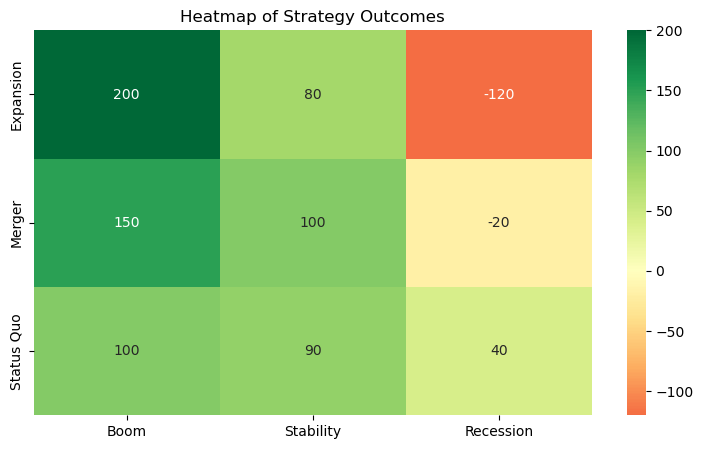

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact

data = { 'Boom': [200, 150, 100], 'Stability': [80, 100, 90], 'Recession': [-120, -20, 40] }

strategies = ['Expansion', 'Merger', 'Status Quo']
df_payoff = pd.DataFrame(data, index=strategies)

display(df_payoff)

plt.figure(figsize=(9, 5))
sns.heatmap(df_payoff, annot=True, fmt="d", cmap="RdYlGn", center=0)
plt.title("Heatmap of Strategy Outcomes")
plt.show()

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
      1. Non-Probabilistic Criteria: The Maximin Approach
  </h2>
</div>

This is the **Conservative (Pessimistic) Strategy**. It is used when the decision-maker cannot or does not want to assign probabilities to future states. 

**Logic:** Identify the worst possible outcome for each strategy and choose the one with the "best" worst-case scenario (maximizing the minimum). This approach focuses on guaranteed minimum returns.

In [12]:
df_payoff['Worst_Case'] = df_payoff[['Boom', 'Stability', 'Recession']].min(axis=1)

best_maximin_strategy = df_payoff['Worst_Case'].idxmax()
maximin_value = df_payoff['Worst_Case'].max()

print(f"Maximin Analysis (Conservative):")
print(df_payoff['Worst_Case'])
print(f"\nRecommended Strategy: {best_maximin_strategy} (Guaranteed: {maximin_value}M)")

Maximin Analysis (Conservative):
Expansion    -120
Merger        -20
Status Quo     40
Name: Worst_Case, dtype: int64

Recommended Strategy: Status Quo (Guaranteed: 40M)


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
      2. Probabilistic Approach: Expected Monetary Value (EMV) & Bayesian Theorem
  </h2>
</div>

In this section, we assume we have estimates for the probability of each economic state **(Bayesian Prior Probabilities)**.

**Given Probabilities:**
- $P(Boom) = 0.30$
- $P(Stability) = 0.50$
- $P(Recession) = 0.20$

**The EMV Criterion:** The EMV is the weighted average of all possible payoffs for a decision. It represents the long-run average outcome if the decision were repeated many times.

In [13]:
probs = np.array([0.3, 0.5, 0.2])

df_payoff['EMV'] = df_payoff[['Boom', 'Stability', 'Recession']].dot(probs)
display(df_payoff[['Boom', 'Stability', 'Recession', 'EMV']])
print(f"Optimal Strategy based on EMV: {df_payoff['EMV'].idxmax()}")

,Boom,Stability,Recession,EMV
Expansion,200,80,-120,76.0
Merger,150,100,-20,91.0
Status Quo,100,90,40,83.0


Optimal Strategy based on EMV: Merger


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
      3. Expected Value of Perfect Information (EVPI)
  </h2>
</div>

**Expected Value of Perfect Information (EVPI)** tells us the maximum amount the CEO should be willing to pay for a perfectly accurate economic forecast (e.g., a "perfect" market research report).

It is calculated as the difference between:
1. **Expected Profit with Perfect Information (EPPI):** Choosing the best option *after* knowing the state of nature.
2. **Maximum EMV:** The best decision we can make *before* having that information.


In [14]:
best_payoff_per_scenario = df_payoff[['Boom', 'Stability', 'Recession']].max()
eppi = best_payoff_per_scenario.dot(probs)
evpi = eppi - df_payoff['EMV'].max()

print(f"Expected Profit with Perfect Info (EPPI): {eppi:.2f} M")
print(f"Current Max EMV (without info): {df_payoff['EMV'].max():.2f} M")
print(f"--- EVPI (Cost of Uncertainty): {evpi:.2f} Million $ ---")

Expected Profit with Perfect Info (EPPI): 118.00 M
Current Max EMV (without info): 91.00 M
--- EVPI (Cost of Uncertainty): 27.00 Million $ ---


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
      4. Sensitivity Analysis
  </h2>
</div>

Sensitivity analysis explores how the optimal decision shifts as our probability estimates change. Use the slider to change the probability of a "Boom" and observe how the EMV of each strategy reacts.


In [15]:
def sensitivity_plot(p_boom):
    remaining = 1 - p_boom
    p_stability = remaining * (0.5/0.7)
    p_recession = remaining * (0.2/0.7)
    
    current_probs = [p_boom, p_stability, p_recession]
    emvs = df_payoff[['Boom', 'Stability', 'Recession']].dot(current_probs)
    
    plt.figure(figsize=(10, 5))
    colors = ['#3498db' if x == emvs.max() else '#bdc3c7' for x in emvs]
    emvs.plot(kind='barh', color=colors)
    plt.axvline(0, color='black', lw=1)
    plt.title(f"Sensitivity Analysis: EMV when P(Boom) = {p_boom:.2f}")
    plt.xlabel("Expected Monetary Value (Million $)")
    plt.xlim(-50, 180)
    plt.show()

interact(sensitivity_plot, p_boom=(0.0, 1.0, 0.05));

interactive(children=(FloatSlider(value=0.5, description='p_boom', max=1.0, step=0.05), Output()), _dom_classe…

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
      5. Risk Analysis: Monte Carlo Simulation
  </h2>
</div>

While EMV gives an average, it doesn't show the distribution of risk. In this simulation, we treat the payoffs as random variables (Normal Distribution) to calculate the **Probability of Loss** for the "Expansion" strategy.

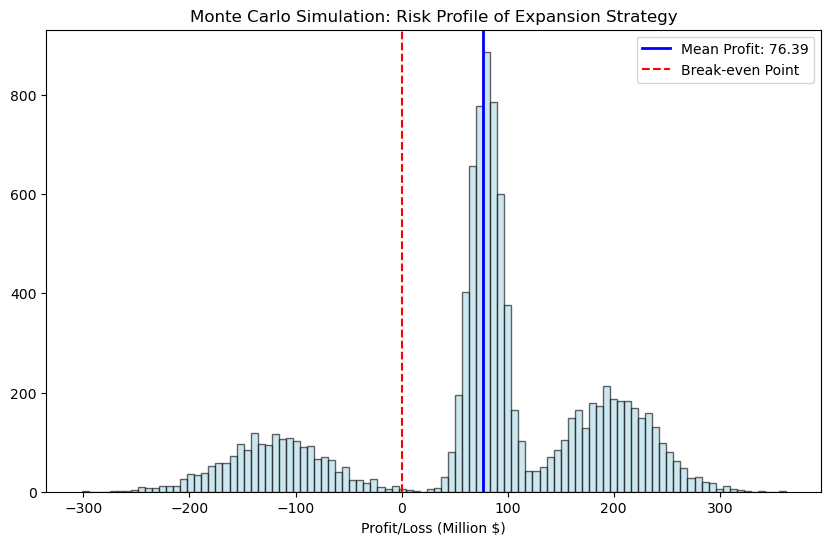

Risk Analysis: The 'Expansion' strategy has a 19.5% chance of negative profit.


In [16]:
iterations = 10000
expansion_sim = []

for i in range(iterations):
    state = np.random.choice(['B', 'S', 'R'], p=[0.3, 0.5, 0.2])
    if state == 'B': profit = np.random.normal(200, 40) 
    elif state == 'S': profit = np.random.normal(80, 15)
    else: profit = np.random.normal(-120, 50)
    
    expansion_sim.append(profit)

plt.figure(figsize=(10, 6))
plt.hist(expansion_sim, bins=100, color='lightblue', edgecolor='black', alpha=0.6)
plt.axvline(np.mean(expansion_sim), color='blue', lw=2, label=f'Mean Profit: {np.mean(expansion_sim):.2f}')
plt.axvline(0, color='red', linestyle='--', label='Break-even Point')
plt.title("Monte Carlo Simulation: Risk Profile of Expansion Strategy")
plt.xlabel("Profit/Loss (Million $)")
plt.legend()
plt.show()

risk_of_loss = (np.array(expansion_sim) < 0).mean() * 100
print(f"Risk Analysis: The 'Expansion' strategy has a {risk_of_loss:.1f}% chance of negative profit.")

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
      6. Decision Tree Analysis
  </h2>
</div>

A **Decision Tree** is a graphical and mathematical tool for analyzing **sequential decisions** under uncertainty. Unlike a simple payoff table, a decision tree can represent multiple stages such as:

- making an initial decision,
- receiving new information,
- observing uncertain events,
- and then making a follow-up decision.

### Why use a Decision Tree?
A payoff matrix is useful for one-shot decisions, but many real managerial problems are **dynamic**. A decision tree allows us to combine all previous concepts into one structure:

- **Decision nodes** represent choices under the manager's control.
- **Chance nodes** represent uncertain events with probabilities.
- **Terminal nodes** represent final outcomes (profit/loss).

### Example Scenario
Suppose the company has a two-stage decision process:

1. First, the manager decides whether to **Buy a Market Report** or **Skip the Report**.
2. If the report is purchased, it may return either:
   - a **Favorable** signal, or
   - an **Unfavorable** signal.
3. Based on that signal, the manager chooses between:
   - **Expansion**
   - **Status Quo**

This is a sequential decision problem because the second decision depends on the information revealed in the first stage.

In [17]:
import pandas as pd

report_cost = 10  
p_favorable = 0.6
p_unfavorable = 0.4

favorable_payoffs = {'Expansion': 180, 'Status Quo': 95}
unfavorable_payoffs = {'Expansion': 20, 'Status Quo': 85}
skip_report_payoffs = {'Expansion': 80, 'Status Quo': 90}

### Step 1: Compute EMV at Each Decision Node
For each decision point, we choose the alternative with the highest EMV.

Then we move backward to evaluate whether buying the report is worth its cost.


In [18]:
def choose_best(payoff_dict):
    best_strategy = max(payoff_dict, key=payoff_dict.get)
    best_value = payoff_dict[best_strategy]
    pruned = {k: v for k, v in payoff_dict.items() if k != best_strategy}
    return best_strategy, best_value, pruned

best_fav_strategy, best_fav_value, pruned_fav = choose_best(favorable_payoffs)
best_unfav_strategy, best_unfav_value, pruned_unfav = choose_best(unfavorable_payoffs)
best_skip_strategy, best_skip_value, pruned_skip = choose_best(skip_report_payoffs)

emv_buy_report = (p_favorable * best_fav_value + p_unfavorable * best_unfav_value) - report_cost
emv_skip_report = best_skip_value

root_options = {'Buy Report': emv_buy_report, 'Skip Report': emv_skip_report}
best_root_decision, best_root_value, pruned_root = choose_best(root_options)

print(f"After Favorable Report -> Choose: {best_fav_strategy}, EMV = {best_fav_value}")
print(f"After Unfavorable Report -> Choose: {best_unfav_strategy}, EMV = {best_unfav_value}")
print(f"If Skip Report -> Choose: {best_skip_strategy}, EMV = {best_skip_value}")
print()
print(f"EMV(Buy Report)  = {emv_buy_report:.2f}")
print(f"EMV(Skip Report) = {emv_skip_report:.2f}")
print()
print(f"Optimal Root Decision: {best_root_decision} with EMV = {best_root_value:.2f}")

After Favorable Report -> Choose: Expansion, EMV = 180
After Unfavorable Report -> Choose: Status Quo, EMV = 85
If Skip Report -> Choose: Status Quo, EMV = 90

EMV(Buy Report)  = 132.00
EMV(Skip Report) = 90.00

Optimal Root Decision: Buy Report with EMV = 132.00


### Step 2: Visualize the Decision Tree with Graphviz
In the diagram below:

- **Squares** represent decision nodes
- **Circles** represent chance nodes
- **Triangles / terminal labels** represent final outcomes
- Branches that are not optimal are marked as **PRUNED**

This provides both a visual and mathematical explanation of the final recommendation.

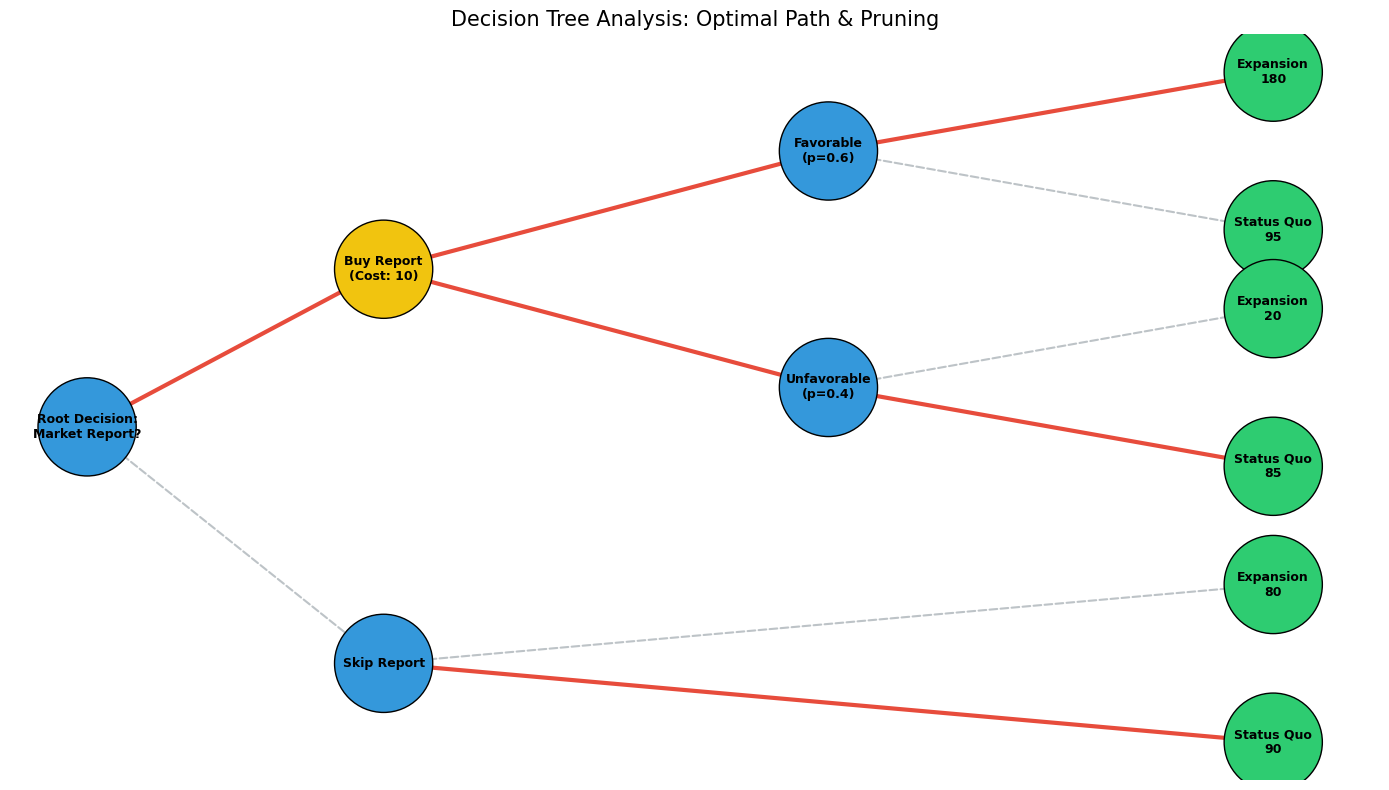

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_decision_tree():
    G = nx.DiGraph()
    nodes = [
        ('Start', 'Root Decision:\nMarket Report?', '#3498db'),
        ('Buy', f'Buy Report\n(Cost: {report_cost})', '#f1c40f'),
        ('Skip', 'Skip Report', '#3498db'),
        ('Fav', f'Favorable\n(p={p_favorable})', '#3498db'),
        ('Unfav', f'Unfavorable\n(p={p_unfavorable})', '#3498db'),
        ('Exp1', f'Expansion\n{favorable_payoffs["Expansion"]}', '#2ecc71'),
        ('SQ1', f'Status Quo\n{favorable_payoffs["Status Quo"]}', '#2ecc71'),
        ('Exp2', f'Expansion\n{unfavorable_payoffs["Expansion"]}', '#2ecc71'),
        ('SQ2', f'Status Quo\n{unfavorable_payoffs["Status Quo"]}', '#2ecc71'),
        ('Exp_S', f'Expansion\n{skip_report_payoffs["Expansion"]}', '#2ecc71'),
        ('SQ_S', f'Status Quo\n{skip_report_payoffs["Status Quo"]}', '#2ecc71')
    ]
    for n, label, color in nodes:
        G.add_node(n, label=label, color=color)
        
    edges = [
        ('Start', 'Buy', best_root_decision == 'Buy Report'),
        ('Start', 'Skip', best_root_decision == 'Skip Report'),
        ('Buy', 'Fav', True),
        ('Buy', 'Unfav', True),
        ('Fav', 'Exp1', best_fav_strategy == 'Expansion'),
        ('Fav', 'SQ1', best_fav_strategy == 'Status Quo'),
        ('Unfav', 'Exp2', best_unfav_strategy == 'Expansion'),
        ('Unfav', 'SQ2', best_unfav_strategy == 'Status Quo'),
        ('Skip', 'Exp_S', best_skip_strategy == 'Expansion'),
        ('Skip', 'SQ_S', best_skip_strategy == 'Status Quo'),
    ]
    plt.figure(figsize=(14, 8))
    pos = {
        'Start': (0, 5),
        'Buy': (2, 7), 'Skip': (2, 2),
        'Fav': (5, 8.5), 'Unfav': (5, 5.5),
        'Exp1': (8, 9.5), 'SQ1': (8, 7.5),
        'Exp2': (8, 6.5), 'SQ2': (8, 4.5),
        'Exp_S': (8, 3), 'SQ_S': (8, 1)
    }

    node_colors = [G.nodes[n]['color'] for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, node_size=5000, node_color=node_colors, edgecolors='black')

    node_labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

    for u, v, optimal in edges:
        color = '#e74c3c' if optimal else '#bdc3c7'
        width = 3 if optimal else 1.5
        style = 'solid' if optimal else 'dashed'
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, 
                               edge_color=color, style=style, arrows=True, arrowsize=20)

    plt.title("Decision Tree Analysis: Optimal Path & Pruning", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_decision_tree()

### Interpretation of the Tree
The tree shows how a sequential decision can be solved from right to left:

1. At the **final decision nodes**, compare the available strategies and keep the one with the larger EMV.
2. Mark the inferior alternative as **pruned**.
3. Move backward to the **chance node** and compute the weighted EMV using probabilities.
4. Finally, compare the root-level alternatives and choose the one with the larger total expected value.

This method is especially useful when:
- information arrives in stages,
- decisions are conditional on observations,
- and managers need a rational rule for adapting strategy over time.
